# RL Training Ground — Adaptive VIO Parameter Tuning

**Approach**: Following [Messikommer et al., ECCV 2024 — "Reinforcement Learning Meets Visual Odometry"](https://arxiv.org/abs/2407.15626), we formulate VIO as a sequential decision process. A lightweight neural agent (Perceiver + MLP, ~300K params) observes map statistics and keypoint distributions at each frame, then selects tunable parameters that were previously hand-tuned.

**Key differences from UZH's work:**
- **Stereo + IMU** → absolute scale, so reward computation is more stable (no Umeyama scale ambiguity)
- **ISAM2 backend** → covariance/degeneracy metrics provide rich state signal
- **More action dimensions** → parallax threshold, observation grid size, loop closure aggressiveness

**Training target**: EuRoC MH_01_easy sequence with frame_step=10

## 1. Install & Import Required Libraries

In [1]:
# # Install RL dependencies (run once)
# %pip install gymnasium stable-baselines3 tensorboard

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

# Project root
PROJECT_ROOT = r"f:\Code\VIO-Tightly"
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# VIO pipeline modules
from data_manager import DataManager
from v_frontend import vFeature
from imu_pipeline import IMUPipeline, IMUCalibration, IMUSample
from vio_optimizer import GraphOptimizer
import gtsam

# RL modules
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback

# Our custom modules
from rl_vio_env import (VIOEnv, ACTION_DIMS, PARALLAX_OPTIONS, MIN_FEATURES_OPTIONS,
                         MIN_OBS_PARALLAX_OPTIONS, LANDMARK_REG_OPTIONS)
from rl_vio_agent import make_vio_policy_kwargs

print(f"gymnasium:   {gym.__version__}")
print(f"Action dims: {ACTION_DIMS}")
print("All imports OK ✓")

gymnasium:   1.3.0
Action dims: [5, 6, 5, 5]
All imports OK ✓


## 2. Load and Parse EuRoC Dataset

Verify the dataset loads correctly and inspect the available data streams (stereo images, IMU, ground truth poses).

Data loaded successfully.
Camera frames:  3682  (184.0s)
IMU samples:    36820  (200 Hz)
GT poses:       36382
Image size:     752 × 480 (EuRoC standard)


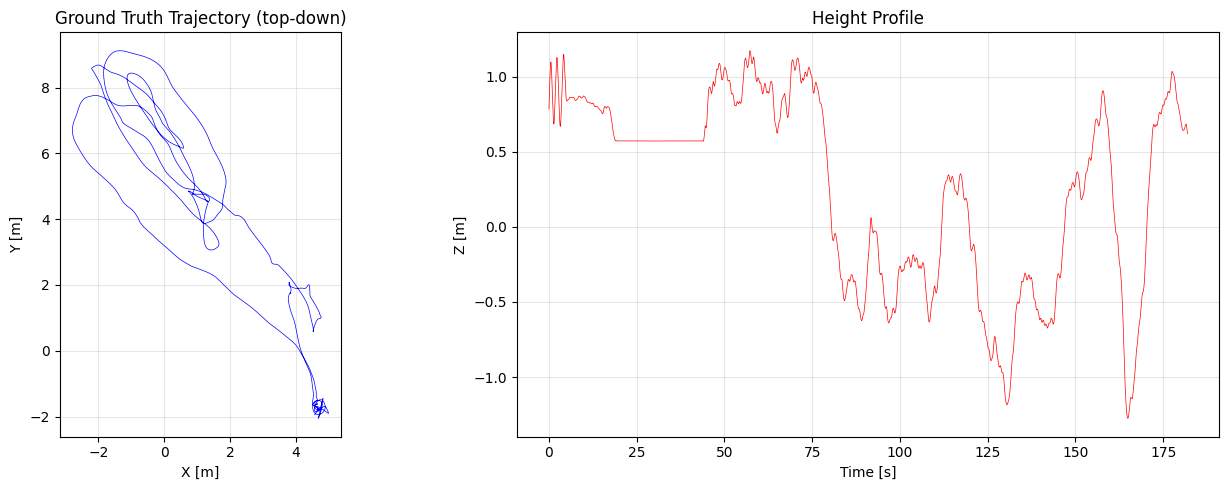

In [3]:
DATA_DIR = "f:/Code/exercise_10/data/MH_01_easy/mav0"
assert os.path.exists(DATA_DIR), f"Dataset not found: {DATA_DIR}"

dm = DataManager(DATA_DIR)
dm.load_data()

# Inspect dataset
n_cam = len(dm.cam_df)
n_imu = len(dm.imu_df)
n_gt  = len(dm.gt_df)
cam_duration = dm.cam_df["timestamp"].iloc[-1] - dm.cam_df["timestamp"].iloc[0]
imu_rate = n_imu / (dm.imu_df["timestamp"].iloc[-1] - dm.imu_df["timestamp"].iloc[0])

print(f"Camera frames:  {n_cam}  ({cam_duration:.1f}s)")
print(f"IMU samples:    {n_imu}  ({imu_rate:.0f} Hz)")
print(f"GT poses:       {n_gt}")
print(f"Image size:     752 × 480 (EuRoC standard)")

# Plot ground truth trajectory
gt = dm.gt_df
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(gt["p_x"], gt["p_y"], 'b-', linewidth=0.5)
axes[0].set_xlabel("X [m]"); axes[0].set_ylabel("Y [m]")
axes[0].set_title("Ground Truth Trajectory (top-down)")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

axes[1].plot(gt["timestamp"] - gt["timestamp"].iloc[0], gt["p_z"], 'r-', linewidth=0.5)
axes[1].set_xlabel("Time [s]"); axes[1].set_ylabel("Z [m]")
axes[1].set_title("Height Profile")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Define VIO Pipeline as Gym Environment

The `VIOEnv` wraps our full stereo VIO pipeline (XFeat/SuperPoint frontend + ISAM2 backend + IMU preintegration) as a `gymnasium.Env`. Each `step()` processes one stereo frame with the agent's chosen parameters.

**Environment Flow:**
```
reset() → initialize VIO pipeline → process frame 0 → return initial observation
step(action) → apply parameters → process frame i → return (obs, reward, done, info)
```

In [4]:
# Create and test the VIO environment
env = VIOEnv(
    data_dir=DATA_DIR,
    frame_step=10,           # Process every 10th frame (matching your main_threaded.py)
    start_frame=400,         # Skip initial static period  (40 * frame_step)
    max_episode_frames=140,   # ~80 frames per episode for faster training iterations
    reward_window=5,         # Sliding window for Umeyama-aligned error
    matcher_type="xfeat",    # Match your current pipeline
)

print("Environment created.")
print(f"  Action space:      {env.action_space}")
print(f"  Observation space: {env.observation_space.shape}")
print(f"  Action dimensions: {ACTION_DIMS}")
print()
print("Action catalogue (4 tunables):")
print(f"  PARALLAX_THRESHOLD:    {PARALLAX_OPTIONS}")
print(f"  MIN_TRACKED_FEATURES:  {MIN_FEATURES_OPTIONS}")
print(f"  MIN_OBS_PARALLAX:      {MIN_OBS_PARALLAX_OPTIONS}")
print(f"  LANDMARK_REG_SIGMA:    {LANDMARK_REG_OPTIONS}")

Environment created.
  Action space:      MultiDiscrete([5 6 5 5])
  Observation space: (815,)
  Action dimensions: [5, 6, 5, 5]

Action catalogue (4 tunables):
  PARALLAX_THRESHOLD:    [1.0, 1.5, 2.5, 3.5, 5.0]
  MIN_TRACKED_FEATURES:  [200, 300, 400, 500, 700, 1000]
  MIN_OBS_PARALLAX:      [0.5, 1.0, 2.0, 3.0, 5.0]
  LANDMARK_REG_SIGMA:    [0.5, 1.0, 1.5, 2.5, 4.0]


## 4. State Space and Action Space

### Observation (what the agent sees)
| Index | Field | Description |
|-------|-------|-------------|
| 0 | n_tracked / 1000 | Tracked feature count (normalized) |
| 1 | n_landmarks / 5000 | Total landmark count |
| 2 | frame_idx / 500 | Temporal position in sequence |
| 3-5 | sliding window ATE | Current, mean, max position error |
| 6-8 | optimizer diagnostics | avg_error/factor, n_landmarks, n_factors |
| 9-11 | covariance eigenvalues | Position uncertainty (σ per axis) |
| 12 | degeneracy flag | 1.0 if degenerate motion detected |
| 13-14 | IMU deltas | ‖Δp‖, ‖Δv‖ from preintegration |
| 15-815 | keypoints (200×4) | Normalized (u,v) + depth_inv + track_age |

### Actions (what the agent controls)
| Action | Options | Effect |
|--------|---------|--------|
| MIN_TRACKED_FEATURES | {200, 300, 400, 500, 700, 1000} | When to trigger new detection |
| OBS_CELL_SIZE | {8, 12, 16, 24, 32} px | Spatial distribution of observations |
| PARALLAX_THRESHOLD | {1.0°, 1.5°, 2.5°, 3.5°, 5.0°} | Landmark quality gate |
| LC_FRAME_GAP | {5, 9, 15, 25} | Loop closure temporal gap |
| KEYFRAME | {skip, insert} | Keyframe selection |

In [5]:
# # Smoke test: run a few steps with random actions to verify the env works
# obs, info = env.reset()
# print(f"Initial observation shape: {obs.shape}")
# print(f"Map stats (first 15):  {obs[:15]}")
# print(f"Keypoints non-zero:    {(obs[15:] != 0).sum()} / {len(obs[15:])}")

# total_reward = 0
# for step_i in range(5):
#     action = env.action_space.sample()
#     obs, reward, terminated, truncated, info = env.step(action)
#     total_reward += reward
#     print(f"  Step {step_i+1}: action={action}, reward={reward:.6f}, "
#           f"obs={info.get('n_observations', 0)} obs, "
#           f"ate_window={info.get('ate_window', 0):.4f}m, "
#           f"done={terminated or truncated}")
#     if terminated or truncated:
#         break

# print(f"\nSmoke test passed ✓  (total reward: {total_reward:.6f})")

## 5. Reward Function

The reward follows the UZH sliding-window approach, adapted for our stereo+IMU system:

$$r = \lambda_1 \cdot \max(-1, \; \epsilon_{\text{target}} - e_{\text{pos}}) - \lambda_2 \cdot a_{\text{keyframe}}$$

- **Position error** $e_{\text{pos}}$: Umeyama-aligned position error at the current frame within a 5-frame sliding window
- **Keyframe penalty**: discourages excessive keyframe insertion (controls runtime)
- $\epsilon_{\text{target}} = 0.2$m: positive reward when error is below this threshold
- $\lambda_1 = 0.01$, $\lambda_2 = 5 \times 10^{-3}$

**Advantage over monocular VO**: Our stereo system has absolute scale, making $e_{\text{pos}}$ directly comparable without scale estimation artifacts.

In [6]:
# Run a baseline episode with FIXED default parameters to establish the baseline ATE
from rl_vio_env import _umeyama_align

def run_baseline_episode(env, default_action):
    """Run one full episode with fixed parameters (the 'heuristic' baseline)."""
    obs, _ = env.reset()
    rewards = []
    ate_errors = []

    for step_i in range(env.max_episode_frames):
        obs, reward, terminated, truncated, info = env.step(default_action)
        rewards.append(reward)
        ate_errors.append(info.get("ate_window", 0.0))
        if terminated or truncated:
            break

    # Compute final ATE over full trajectory
    if len(env._est_positions) >= 3:
        _, errors = _umeyama_align(
            np.array(env._est_positions), np.array(env._gt_positions)
        )
        final_ate = float(np.sqrt(np.mean(errors**2)))
    else:
        final_ate = float("inf")

    return rewards, ate_errors, final_ate

# Default action: PARALLAX=2.5°, MIN_FEAT=500, MIN_OBS_PARALLAX=2°, LANDMARK_REG=1.5m
default_action = np.array([2, 3, 2, 2])  # indices into option arrays
print("Running baseline episode with default parameters...")
print(f"  PARALLAX={PARALLAX_OPTIONS[2]}°, MIN_FEAT={MIN_FEATURES_OPTIONS[3]}, "
      f"MIN_OBS_PARALLAX={MIN_OBS_PARALLAX_OPTIONS[2]}°, LANDMARK_REG={LANDMARK_REG_OPTIONS[2]}m")

baseline_rewards, baseline_ates, baseline_final_ate = run_baseline_episode(env, default_action)

print(f"\nBaseline episode complete:")
print(f"  Frames processed: {len(baseline_rewards)}")
print(f"  Total reward:     {sum(baseline_rewards):.6f}")
print(f"  Final ATE (RMSE): {baseline_final_ate:.4f} m")
print(f"  Mean window ATE:  {np.mean(baseline_ates):.4f} m")

Running baseline episode with default parameters...
  PARALLAX=2.5°, MIN_FEAT=500, MIN_OBS_PARALLAX=2.0°, LANDMARK_REG=1.5m
Data loaded successfully.
Initializing XFeat...


Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main


XFeat loaded on cpu (64D descriptors)
Initializing XFeat...
XFeat loaded on cpu (64D descriptors)


Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main


  Tracked 0 < 700, detecting new features (INIT: full stereo match)...
Filtered 8/331 points with reprojection error and depth constraints.
Left reproj mean error: 0.17px, Right reproj mean error: 0.17px
  Added 323 new features (total will be 323)
[Frame 0] Tracked:0 New:323 Obs:323 NewLM:323 MedianDisp:0.00px
Optical flow [IMU+P1]: valid=304/323  mean_fb_err=0.0532px  median_disp=19.82px
  Tracked 304 < 500, detecting new features (INIT: full stereo match)...
Filtered 12/465 points with reprojection error and depth constraints.
Left reproj mean error: 0.16px, Right reproj mean error: 0.16px
  Added 453 new features (total will be 757)
[Frame 1] Tracked:304 New:453 Obs:757 NewLM:453 MedianDisp:19.82px
Optical flow [IMU+P1]: valid=756/757  mean_fb_err=0.0055px  median_disp=0.54px
[Frame 2] Tracked:756 New:0 Obs:756 NewLM:0 MedianDisp:0.54px
  Rejecting landmark 0 due to low parallax (0.8°)
  Rejecting landmark 1 due to low parallax (1.2°)
  Rejecting landmark 2 due to low parallax (1.3

## 6. Build RL Agent with Stable-Baselines3

**Architecture** (following UZH's Perceiver-based agent):
- **Variable Encoder**: 8 learned query tokens attend to up to 200 keypoints via 4-head cross-attention
- **Map Stats MLP**: 2-layer MLP processes 15-dim fixed-size map statistics
- **Combined MLP**: 2-layer → multi-discrete action heads

**Training**: PPO (Proximal Policy Optimization) with:
- Short discount factor γ=0.6 (actions mainly affect near-future frames)
- n_steps=80 (one full episode per rollout)
- Batch size=40 (two sub-batches per rollout)

In [7]:
# Create fresh environment for training
train_env = VIOEnv(
    data_dir=DATA_DIR,
    frame_step=10,
    start_frame=420,
    max_episode_frames=120,
    reward_window=5,
    matcher_type="xfeat",
)

# Build PPO agent with our custom Perceiver-based feature extractor
policy_kwargs = make_vio_policy_kwargs(features_dim=128)

model = PPO(
    "MlpPolicy",
    train_env,
    policy_kwargs=policy_kwargs,
    learning_rate=3e-4,
    n_steps=120,             # One full episode per rollout
    batch_size=60,           # Two minibatches per epoch
    n_epochs=10,             # PPO update epochs per rollout
    gamma=0.9,               # Longer horizon — parameter choices compound over time
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,           # Encourage exploration initially
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1,
    tensorboard_log="./rl_vio_logs/",
)

# Count parameters
total_params = sum(p.numel() for p in model.policy.parameters())
trainable_params = sum(p.numel() for p in model.policy.parameters() if p.requires_grad)
print(f"\nAgent created:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Policy architecture:  {model.policy.__class__.__name__}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Agent created:
  Total parameters:     254,358
  Trainable parameters: 254,358
  Policy architecture:  ActorCriticPolicy


## 7. Training Loop with Episode Logging

Custom callback records per-episode metrics: total reward, final ATE, and chosen actions.

In [ ]:
class VIOTrainingCallback(BaseCallback):
    """Logs per-episode metrics during PPO training.
    
    Saves model checkpoints every episode so we can later pick the best
    weights from the best consecutive 5-episode window (by mean ATE).
    """

    def __init__(self, checkpoint_dir="./rl_checkpoints", verbose=0):
        super().__init__(verbose)
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        self.episode_rewards = []
        self.episode_ates = []
        self.episode_lengths = []
        self.episode_actions = []
        self._current_episode_reward = 0.0
        self._current_episode_actions = []
        self._current_episode_length = 0

    def _log(self, msg):
        import sys
        sys.stderr.write(msg + "\n")
        sys.stderr.flush()

    def _on_step(self) -> bool:
        reward = self.locals["rewards"][0]
        self._current_episode_reward += reward
        self._current_episode_length += 1

        action = self.locals["actions"][0]
        self._current_episode_actions.append(action.copy())

        done = self.locals["dones"][0]
        if done:
            info = self.locals["infos"][0]
            ate = info.get("final_ate", float("inf"))

            self.episode_rewards.append(self._current_episode_reward)
            self.episode_ates.append(ate)
            self.episode_lengths.append(self._current_episode_length)
            self.episode_actions.append(np.array(self._current_episode_actions))

            ep_num = len(self.episode_rewards)

            # Save checkpoint every episode
            ckpt_path = os.path.join(self.checkpoint_dir, f"ep_{ep_num:04d}")
            self.model.save(ckpt_path)

            self._log(f"{'='*60}")
            self._log(f"Episode {ep_num} complete:")
            self._log(f"  Frames:       {self._current_episode_length}")
            self._log(f"  Total reward: {self._current_episode_reward:.6f}")
            self._log(f"  Final ATE:    {ate:.4f} m")

            actions_arr = np.array(self._current_episode_actions)
            if len(actions_arr) > 0:
                self._log(f"  Avg actions:  "
                      f"parallax={PARALLAX_OPTIONS[int(np.median(actions_arr[:,0]))]:.1f}°, "
                      f"min_feat={MIN_FEATURES_OPTIONS[int(np.median(actions_arr[:,1]))]}, "
                      f"obs_par={MIN_OBS_PARALLAX_OPTIONS[int(np.median(actions_arr[:,2]))]:.1f}°, "
                      f"lm_reg={LANDMARK_REG_OPTIONS[int(np.median(actions_arr[:,3]))]:.1f}m")
            self._log(f"{'='*60}")

            self._current_episode_reward = 0.0
            self._current_episode_actions = []
            self._current_episode_length = 0

        return True

    def get_best_window(self, window_size=5):
        """Find the best consecutive window of `window_size` episodes by mean ATE.
        
        Returns:
            best_start: Start index of the best window
            best_mean_ate: Mean ATE of the best window
            best_checkpoint: Path to the checkpoint at the END of the best window
        """
        ates = self.episode_ates
        if len(ates) < window_size:
            # Not enough episodes, return last
            return 0, float("inf"), None

        best_mean = float("inf")
        best_start = 0
        for i in range(len(ates) - window_size + 1):
            window = ates[i:i + window_size]
            # Skip windows with inf
            if any(a == float("inf") for a in window):
                continue
            mean_ate = np.mean(window)
            if mean_ate < best_mean:
                best_mean = mean_ate
                best_start = i

        # The checkpoint at the END of the best window
        best_end_ep = best_start + window_size  # 1-indexed episode number
        best_ckpt = os.path.join(self.checkpoint_dir, f"ep_{best_end_ep:04d}.zip")
        if not os.path.exists(best_ckpt):
            best_ckpt = None

        return best_start, best_mean, best_ckpt

print("Training callback defined ✓ (with checkpointing + best-window selection)")

Training callback defined ✓


In [ ]:
# ============================================================
# TRAINING — adjust N_EPISODES to control training duration
# ============================================================
import warnings, logging, io, contextlib

# Suppress rich/ipywidgets conflict in Jupyter
warnings.filterwarnings("ignore", message="install.*ipywidgets")

N_EPISODES = 100   # Number of episodes to train
                   # Each episode = 80 frames × ~50ms = ~4 seconds of VIO
                   # Total: ~100 episodes × 80 steps = 8000 PPO timesteps

total_timesteps = N_EPISODES * train_env.max_episode_frames
callback = VIOTrainingCallback(verbose=1)

print(f"Starting training: {N_EPISODES} episodes, {total_timesteps} total timesteps")
print(f"Baseline ATE: {baseline_final_ate:.4f} m (target to beat)\n")

# Redirect VIO pipeline's verbose prints to devnull during training
# to avoid rich/Jupyter recursion crash. Callback still prints episode summaries.
_devnull = io.StringIO()
with contextlib.redirect_stdout(_devnull):
    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
        progress_bar=False,  # Disable rich progress bar (causes RecursionError in Jupyter)
    )

print(f"\nTraining complete! {len(callback.episode_rewards)} episodes finished.")

# --- Pick best weights from best consecutive 5-episode window ---
best_start, best_mean_ate, best_ckpt = callback.get_best_window(window_size=5)
print(f"\nBest 5-episode window: episodes {best_start+1}-{best_start+5}")
print(f"  Mean ATE: {best_mean_ate:.4f} m")
print(f"  ATEs: {[f'{a:.3f}' for a in callback.episode_ates[best_start:best_start+5]]}")
if best_ckpt and os.path.exists(best_ckpt):
    model = PPO.load(best_ckpt, env=train_env)
    print(f"  Loaded best checkpoint: {best_ckpt}")
else:
    print(f"  (using final model weights)")

Starting training: 30 episodes, 3600 total timesteps
Baseline ATE: 0.1386 m (target to beat)



Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main
Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main


KeyboardInterrupt: 

## 8. Evaluate Learned Policy on EuRoC Sequence

Run the trained agent and compare its ATE against the baseline (fixed default parameters).

In [13]:
# Evaluate: run the trained agent on the same sequence
eval_env = VIOEnv(
    data_dir=DATA_DIR,
    frame_step=10,
    start_frame=400,
    max_episode_frames=80,
    reward_window=5,
    matcher_type="xfeat",
)

obs, _ = eval_env.reset()
rl_rewards = []
rl_ates = []
rl_actions_log = []

for step_i in range(eval_env.max_episode_frames):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    rl_rewards.append(reward)
    rl_ates.append(info.get("ate_window", 0.0))
    rl_actions_log.append(action.copy())
    if terminated or truncated:
        break

# Final ATE
if len(eval_env._est_positions) >= 3:
    _, rl_errors = _umeyama_align(
        np.array(eval_env._est_positions), np.array(eval_env._gt_positions)
    )
    rl_final_ate = float(np.sqrt(np.mean(rl_errors**2)))
else:
    rl_final_ate = float("inf")

print(f"{'='*60}")
print(f"EVALUATION RESULTS")
print(f"{'='*60}")
print(f"  Baseline ATE (RMSE): {baseline_final_ate:.4f} m")
print(f"  RL Agent ATE (RMSE): {rl_final_ate:.4f} m")
improvement = (baseline_final_ate - rl_final_ate) / baseline_final_ate * 100
print(f"  Improvement:         {improvement:+.1f}%")
print(f"  Baseline reward:     {sum(baseline_rewards):.6f}")
print(f"  RL Agent reward:     {sum(rl_rewards):.6f}")
print(f"{'='*60}")

# Save model
model.save("rl_vio_agent_mh01")
print("\nModel saved to rl_vio_agent_mh01.zip")

Data loaded successfully.
Initializing XFeat...


Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main


XFeat loaded on cpu (64D descriptors)
Initializing XFeat...
XFeat loaded on cpu (64D descriptors)


Using cache found in C:\Users\liors/.cache\torch\hub\verlab_accelerated_features_main


  Tracked 0 < 700, detecting new features (INIT: full stereo match)...
Filtered 8/331 points with reprojection error and depth constraints.
Left reproj mean error: 0.17px, Right reproj mean error: 0.17px
  Added 323 new features (total will be 323)
[Frame 0] Tracked:0 New:323 Obs:323 NewLM:323 MedianDisp:0.00px
Optical flow [IMU+P1]: valid=304/323  mean_fb_err=0.0532px  median_disp=19.82px
  Tracked 304 < 1000, detecting new features (INIT: full stereo match)...
Filtered 12/465 points with reprojection error and depth constraints.
Left reproj mean error: 0.16px, Right reproj mean error: 0.16px
  Added 453 new features (total will be 757)
[Frame 1] Tracked:304 New:453 Obs:757 NewLM:453 MedianDisp:19.82px
Optical flow [IMU+P1]: valid=756/757  mean_fb_err=0.0055px  median_disp=0.54px
  Tracked 756 < 1000, detecting new features (INIT: full stereo match)...
Filtered 14/445 points with reprojection error and depth constraints.
Left reproj mean error: 0.14px, Right reproj mean error: 0.14px


## 9. Visualize Training Curves and Trajectory Comparisons

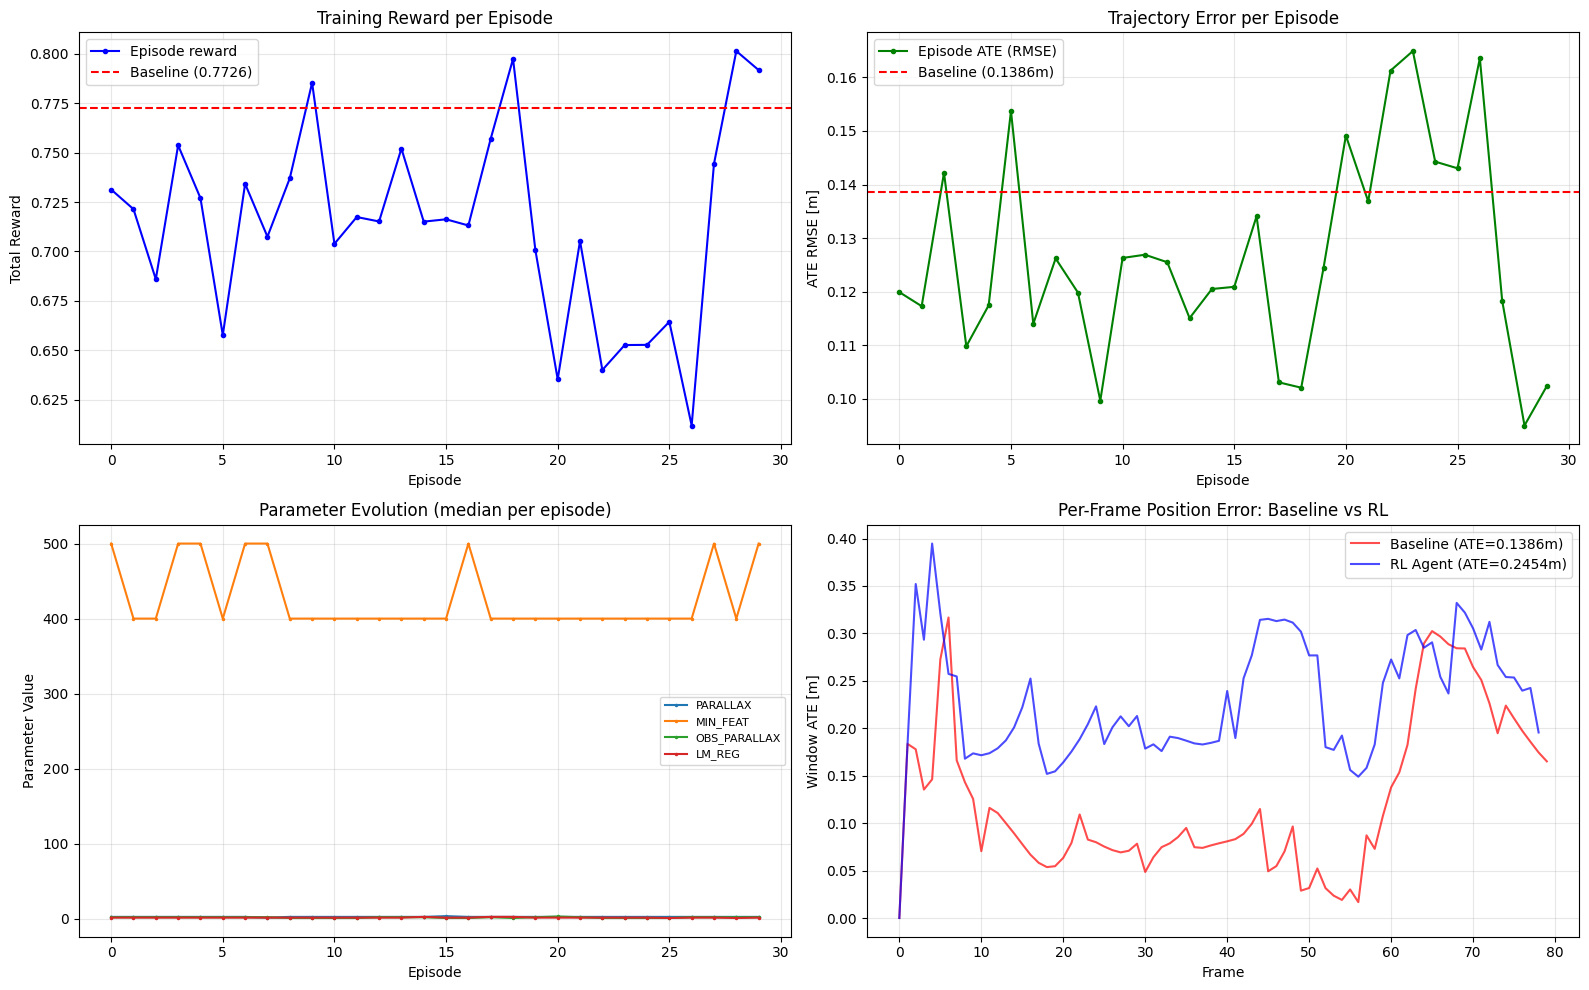

Results saved to rl_training_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Training reward curve ---
ax = axes[0, 0]
ax.plot(callback.episode_rewards, 'b-o', markersize=3, label="Episode reward")
ax.axhline(y=sum(baseline_rewards), color='r', linestyle='--', label=f"Baseline ({sum(baseline_rewards):.4f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.set_title("Training Reward per Episode")
ax.legend()
ax.grid(True, alpha=0.3)

# --- 2. ATE evolution ---
ax = axes[0, 1]
ax.plot(callback.episode_ates, 'g-o', markersize=3, label="Episode ATE (RMSE)")
ax.axhline(y=baseline_final_ate, color='r', linestyle='--', label=f"Baseline ({baseline_final_ate:.4f}m)")
ax.set_xlabel("Episode")
ax.set_ylabel("ATE RMSE [m]")
ax.set_title("Trajectory Error per Episode")
ax.legend()
ax.grid(True, alpha=0.3)

# --- 3. Action evolution (median per episode) ---
ax = axes[1, 0]
action_names = ["PARALLAX", "MIN_FEAT", "OBS_PARALLAX", "LM_REG"]
action_options = [PARALLAX_OPTIONS, MIN_FEATURES_OPTIONS, MIN_OBS_PARALLAX_OPTIONS, LANDMARK_REG_OPTIONS]

for act_idx, (name, options) in enumerate(zip(action_names, action_options)):
    if len(callback.episode_actions) > 0:
        medians = []
        for ep_actions in callback.episode_actions:
            median_idx = int(np.median(ep_actions[:, act_idx]))
            medians.append(options[min(median_idx, len(options)-1)])
        ax.plot(medians, label=name, marker='.', markersize=3)

ax.set_xlabel("Episode")
ax.set_ylabel("Parameter Value")
ax.set_title("Parameter Evolution (median per episode)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- 4. Per-frame ATE comparison: Baseline vs RL Agent ---
ax = axes[1, 1]
n_baseline = min(len(baseline_ates), 80)
n_rl = min(len(rl_ates), 80)
ax.plot(range(n_baseline), baseline_ates[:n_baseline], 'r-', alpha=0.7, label=f"Baseline (ATE={baseline_final_ate:.4f}m)")
ax.plot(range(n_rl), rl_ates[:n_rl], 'b-', alpha=0.7, label=f"RL Agent (ATE={rl_final_ate:.4f}m)")
ax.set_xlabel("Frame")
ax.set_ylabel("Window ATE [m]")
ax.set_title("Per-Frame Position Error: Baseline vs RL")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rl_training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Results saved to rl_training_results.png")

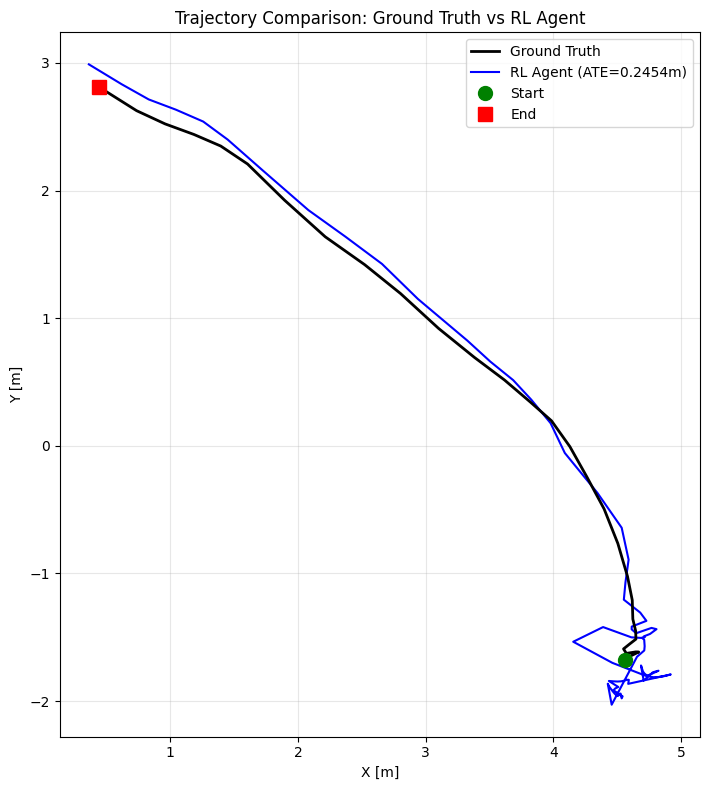

In [12]:
# Trajectory comparison: top-down view
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Ground truth (full sequence segment)
gt_pos = np.array(eval_env._gt_positions)
ax.plot(gt_pos[:, 0], gt_pos[:, 1], 'k-', linewidth=2, label="Ground Truth", zorder=3)

# RL Agent trajectory
rl_pos = np.array(eval_env._est_positions)
if len(rl_pos) >= 3:
    aligned_rl, _ = _umeyama_align(rl_pos, gt_pos[:len(rl_pos)])
    ax.plot(aligned_rl[:, 0], aligned_rl[:, 1], 'b-', linewidth=1.5, label=f"RL Agent (ATE={rl_final_ate:.4f}m)", zorder=2)

# Start/end markers
ax.plot(gt_pos[0, 0], gt_pos[0, 1], 'go', markersize=10, zorder=4, label="Start")
ax.plot(gt_pos[-1, 0], gt_pos[-1, 1], 'rs', markersize=10, zorder=4, label="End")

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Trajectory Comparison: Ground Truth vs RL Agent")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()